# Demonstration: Loading trained model and visualizing the results

In [2]:

import numpy as np
from tqdm import tqdm
import torch
import os
os.environ['CUDA_VISIBLE_DEVICES']  = "0"
import pprint
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt 
from diffusionsr.datasets.dataset import SimulationXZDataset
import wandb
from diffusionsr.analysis.sampling import predict_streamlined_ddim_diffusion
from diffusionsr.analysis.analysis_functions import initialize_diffusion, predict_lrenc, predict_refactored_diffusion, load_encoder


ModuleNotFoundError: No module named 'models'

### Define results directory and general parameters


Load in WandB model by entering the relevant information below. If no WandB entry is available, load the saved .yml file from the runs folder as the `config` dictionary, or fill in the fields manually. 

In [ ]:
# Load model configuration. Either point CONFIG_PATH at a local YAML under
# ../configs/, or set WANDB_RUN (e.g., 'username/project/run_id') to pull
# the saved configuration from a Weights & Biases run.
CONFIG_PATH = None  # e.g., '../configs/ss316l_updated_simulations.yml'
WANDB_RUN = None    # e.g., 'fogoke/Flow3D_SuperResolution/p4c77tn2'

device = 'cuda' if torch.cuda.is_available() else 'cpu'

if CONFIG_PATH is not None:
    import yaml
    with open(CONFIG_PATH, 'r') as f:
        config = yaml.safe_load(f)
elif WANDB_RUN is not None:
    run = wandb.Api().run(WANDB_RUN)
    config = dict(run.config)
else:
    raise ValueError("Set either CONFIG_PATH or WANDB_RUN to load a model configuration.")

print("Loaded Configurations")
pprint.pprint(config)


In [4]:
# Paths to saved model files, establishing model configuration
diffusion_results_dir = config['restart_dir']
encoder_results_dir = config['encoder_results_dir']
encode_bool = config['encoding'] == 'True'

batch_size = 1
downscale_method = 'direct'
# Create folder to store analyzed data
analysis_folder = f'analyzed_figures/{config["timesteps"]}_{config["conditioning"]}_{config["schedule"]}_downscale_{downscale_method}'
os.makedirs(analysis_folder, exist_ok = True)
data_folder = config['root_folder']


In [5]:
# Create dataset
train_dataset = SimulationXZDataset(downscale_method = downscale_method, split = 'train', root_folder = data_folder , return_info = True)
test_dataset = SimulationXZDataset(downscale_method =downscale_method, split = 'test', root_folder = data_folder, return_info = True)
dev_dataset = SimulationXZDataset(downscale_method = downscale_method, split = 'dev', root_folder = data_folder, return_info = True)

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False, drop_last=True)
dev_dataloader = DataLoader(dev_dataset, batch_size=1, shuffle=False, drop_last=True)
test_dataloader = DataLoader(test_dataset, batch_size=1, shuffle=False, drop_last=True)

# load in saved model from WandB config
diff_model = initialize_diffusion(diff_dir=config['restart_dir'],
                                  enc_dir=config['encoder_results_dir'],
                                  datasets=[train_dataset,
                                            dev_dataset, test_dataset],
                                  timesteps=config["timesteps"],
                                  conditioning=config["conditioning"],
                                  encoding=config['encoding'],
                                  schedule=config["schedule"],
                                  device=device)


lr_enc = load_encoder(encoder_results_dir, dataset = train_dataset)


Using normalize method: ... standardize
Using all 2 fields
Processing dataset with 2 fields


IndexError: index 0 is out of bounds for axis 0 with size 0

### Sampling from trained model

Relevant Parameters:


`ddim` controls whether to use an implicit or explicit sampler



`skip` controls the speed up factor for the DDIM model


Data loader variables:

`res`: Residual between high-fidelity and low-fidelity samples


`hr`: High-fidelity sample


`lr`: Low-fidelity sample


`upscaled_lr`: Bicubic Upscaled low-fidelity sample


`info_full`: Metadata

In [ ]:
skip = 50

for batch_idx, (res, hr, lr, upscaled_lr, info_full) in tqdm(enumerate(test_dataloader), total = len(test_dataloader) ):
    # Run input through CNN encoder 
    input, result_encoder, target = predict_lrenc(lr_enc = lr_enc,
                                                  res = res, 
                                                  hr = hr, 
                                                  lr = lr, upscaled_lr = upscaled_lr,
                                                  train_dataset = train_dataset)
    
     # Run input through both CNN encoder and diffusion finetuning
    input, result_diffusion, target = predict_refactored_diffusion(diff_model = diff_model, 
                                                                   lr_enc = lr_enc, 
                                                                   res = res, 
                                                                   hr = hr, 
                                                                   lr =lr, 
                                                                   upscaled_lr = upscaled_lr, 
                                                                   dataset = test_dataloader.dataset, 
                                                                   sampler = 'DDPM'
                                                                   )
    # Result for analytical resizing instead of using ML
    upscaled_lr_data = test_dataloader.dataset.unscale_data(upscaled_lr, input_type = 'upscaled_lr')



### Plotting sample results

NameError: name 'test_dataloader' is not defined

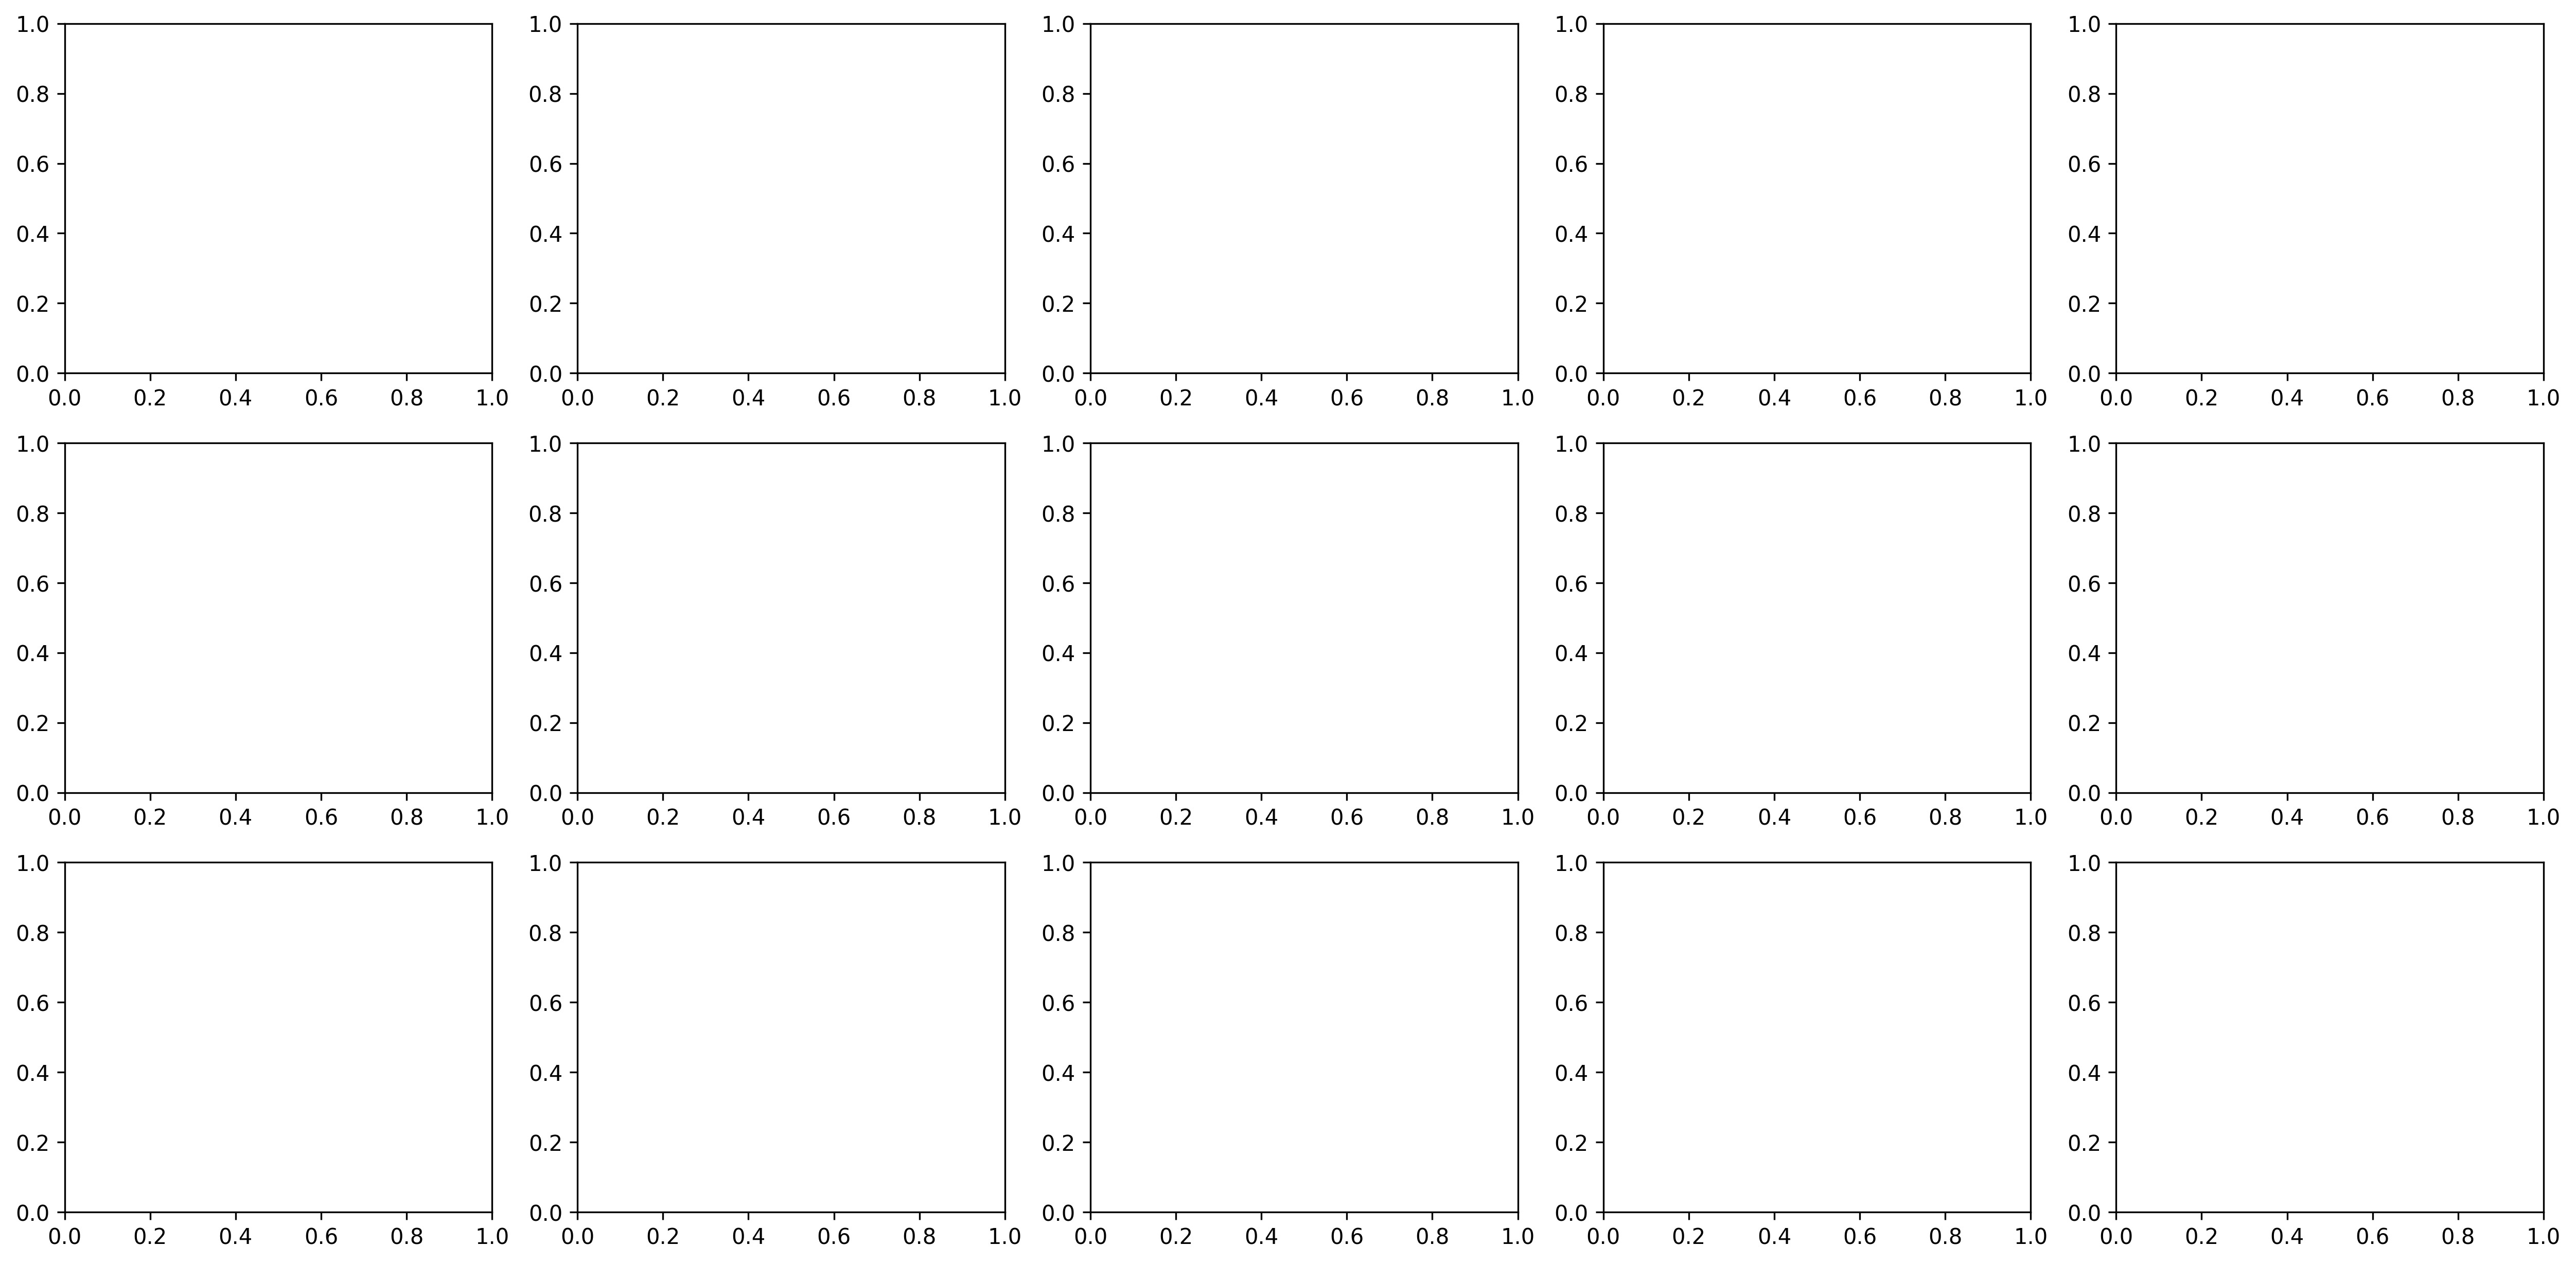

In [22]:
SCALING_FACTOR = 1 # controls plot size
FIGURE_HSIZE = 2.8 * 7.4 # controls plot width
timesteps = 1000 # timesteps for sampler (should match config['timesteps'])
skip = 50 # skip for sampler 

labels = ['Input', 'Bicubic Upscaling', 'CNN', 'Diffusion', 'Target']
batch_idxs = [399, 2617, 1708]  # p_v_: 260v900 364v900 400v650

for k in range(10):
    fig, axs = plt.subplots(
        nrows=3, ncols=5,
        figsize=(FIGURE_HSIZE * SCALING_FACTOR, 10 * SCALING_FACTOR),
        dpi=300
    )
    fig.patch.set_alpha(0)
    
    for j, (row, batch_index) in enumerate(zip(axs, batch_idxs)):
        for batch_idx, (res, hr, lr, upscaled_lr, info_full) in tqdm(
            enumerate(test_dataloader), total=len(test_dataloader)
        ):
            if batch_idx == batch_index:
                input, result, target = predict_lrenc(
                    lr_enc, res, hr, lr, upscaled_lr, train_dataset
                )
                input, result_diffusion, target = predict_refactored_diffusion(
                    diff_model, lr_enc, res, hr, lr, upscaled_lr,
                    test_dataloader.dataset, sampler='DDPM'
                )
                upscaled_lr_data = test_dataloader.dataset.unscale_data(
                    upscaled_lr, input_type='upscaled_lr'
                )
                
                for i, (ax, array, label) in enumerate(
                    zip(row, [input, upscaled_lr_data, result, result_diffusion, target], labels)
                ):
                    division_factor = 2 if i == 0 else 1
                    bound = 10 if i == 0 else 20

                    xx, yy = np.meshgrid(
                        np.arange(28 // division_factor) * 10 * division_factor,
                        np.arange(20 // division_factor) * 10 * division_factor
                    )
                    
                    im = ax.pcolormesh(
                        xx, yy,
                        array[0, 0][12 // division_factor:40 // division_factor, bound:-bound].T,
                        vmin=293, vmax=5000, cmap='jet'
                    )
                    ax.axis('equal')
                    ax.set_ylim([yy.min(), yy.max()])
                    ax.set_title(label, fontsize=15)
                    ax.xaxis.set_tick_params(labelbottom=False)
                    ax.yaxis.set_tick_params(labelleft=False)
                    ax.set_xticks([])
                    ax.set_yticks([])

                    if j == len(axs) - 1 and i == 0:
                        ax.set_ylabel(r'z $[\mu m]$')
                        ax.set_xlabel(r'x $[\mu m]$')
            elif batch_idx > batch_index:
                break

    fig.subplots_adjust(wspace=0.01)

    # Add colorbar
    cax = fig.add_axes([0.91, 0.12, 0.02, 0.77])
    clb = fig.colorbar(im, cax=cax)
    clb.set_ticks([293, 1000, 2000, 3000, 4000, 5000])
    clb.ax.set_title(r'T$[K]$', fontsize=15)

    plt.savefig(os.path.join(analysis_folder, 'sample.png'))
    plt.clf()

### Investigating influence of DDIM steps

In [ ]:
for skip in [1, 10, 50, 100, 200, 500, 1000, 2000][::-1]:
    input, result_ddim, target, _, _ = predict_streamlined_ddim_diffusion(diff_model.model,
                                                                        hr = hr, 
                                                                            lr = lr,
                                                                            x_e = x_e,
                                                                            dataset = test_dataset,
                                                                            timesteps = timesteps,
                                                                            skip = skip,
                                                                            schedule = 'linear')
    plt.imshow(result_ddim[-1][0].T, cmap = 'jet', origin = 'lower', vmin = 293, vmax = 5000)
    plt.title(f"Skip: {skip}")
    plt.show()
    plt.imshow(result_ddim[-1][0].T, cmap = 'jet', origin = 'lower', vmin = 293, vmax = 1700)
    plt.title(f"Skip: {skip}")
    plt.show()